In the 1700s Galileo was posed a simple probability problem by his patron, the Grand Duke of Tuscany. The Duke wanted to know why, when he counted the sum of three dice, he got an equal number of combinations (he counted 6) for the sums 9,10,11, and 12. Yet, gamblers knew that getting 10 or 11 was more likely than getting 9 or 12. The solution was basically that the Duke was counting wrong. The Duke was, correctly, counting getting all 3s as single way of getting 9. But he was also counting getting two 3s and a 4 as a single outcome. But this is wrong since any of the die can be 4, with the other two being threes: <3,3,4>, <3,4,3>, or <4,3,3>. So there are actually three ways of getting the dice to sum to 10 with two 3s and a four. 

This is pretty straight forward stuff nowadays. What is interesting about this example is that gamblers knew the answer, which they would've had to learn from experience and observation since they did not yet have the benefit of a well developed mathematics of probability. How many times would you have to throw three dice before you could confidently say that the sum of 10 is different than the sum of 9? This can be solved both analytically and with simulation. I start with a simple simulation below.

#### Simulating Dice Rolls

The python code here simulates a large number of 3 dice rolls and stores the sum for each roll. We can then look at differences in the rates of occurance between different dice sums as the number of rolls increases. I chose to compare 9 vs. 10. 

In [3]:
import random
import numpy as np
import seaborn as sns
from scipy.stats import norm

In [4]:
# Roll three die and sum, count occurrences
total_rolls = 50000
n = []
prop_compare = []
frequencies = [0 for x in range(17)]
p1 = 25/216
p2 = 27/216
for i in range(total_rolls):
    n.append(i + 1)
    dice_sum = sum([random.randrange(1,7) for j in range(3)])
    frequencies[dice_sum - 3] += 1
    # Compare proportion with sum = 9 and sum = 10
    prop_compare.append((frequencies[9-3] - frequencies[10-3])/n[i])

Text(0.5, 1.0, 'Difference in Estimated Probabilites \n by log(Number of Rolls)')

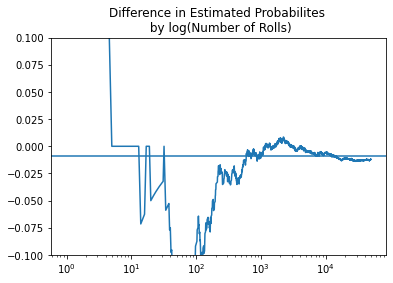

In [16]:
plot = sns.lineplot(x = n, y = prop_compare)
plot.set(ylim = (-.1,.1), xscale ="log")
plot.axhline(p1 - p2)
plot.set_title("Difference in Estimated Probabilites \n by log(Number of Rolls)")

We can see from the plot that the estimated difference jumps around a lot and really doesn't start to stabilize around the line until more than 10,000 rolls. 

Analytical Solution here: https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.571.2708&rep=rep1&type=pdf

In [8]:
def sample_size_calc(p1, p2,alpha = .05, power = .8, k = 1):
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    real_difference = p1 - p2
    samp_size = round((((z_alpha + z_beta)**2)/(real_difference)**2)*(p1*(1-p1)/k + p2*(1-p2)),0)
    return samp_size

[sample_size_calc(p1 = p1, p2 = p2, power = i) for i in [.8, .9, .95, .99]]

[19383.0, 25948.0, 32090.0, 45371.0]

In [14]:
#std error as a function of sample size
def std_error_calc(sample_size):
    return ((p1*(1-p1) + p2*(1-p2))/(sample_size/2))**(1/2)
    
std_list = [std_error_calc(n) for n in range(1,10000)]    

<AxesSubplot:>

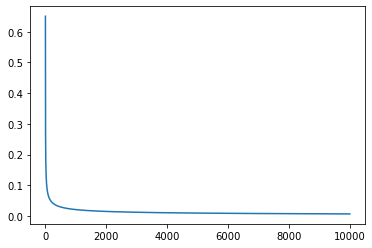

In [23]:
samp_sizes = list(range(1,10000))
sns.lineplot(x = samp_sizes, y = std_list)

In [22]:
samp_sizes

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185